# Chapter 8 (Economic Modeling) — DICE Carbon-Cycle & Climate Module

Port of `chap8_dice12a.m`, `chap8_dice12b.m`, `chap8_dice12c.m`,
`chap8_dice13a.m`, `chap8_dice13b.m`, `chap8_dice13c.m` — DICE's linear
carbon-cycle and 2-layer-temperature box model, taken in isolation from the
rest of the economy.

## A note on reconstruction

Every script in this notebook calls one of two functions,
`dice_temperature_matrix(Delta_t, scale)` and
`dice_temperature_simulation(t_0, t_end, Delta_t, Y_fn, mu_fn, ...)`, that
**exist nowhere in the archive** — not in `QuantToolbox/`, not in
`HSF/0. Toolbox/`, not as a compiled `.p`-file (confirmed by an archive-wide
grep for `function.*dice`). There is nothing to port for these two
functions; they are reconstructed below from the standard, widely published
DICE-2013R specification (Nordhaus, *DICE-2013R: Introduction and User's
Manual*, 2013, revised 2017 — the model's carbon-cycle and climate
equations are also reproduced in dozens of secondary papers and the public
DICE GAMS/MATLAB code).

**Confidence is not uniform across the two functions.** The carbon-cycle
and temperature *box-model* constants (`b12`, `b23`, `c1`, `c3`, `c4`,
`fco22x`, `t2xco2`, and the equilibrium reservoir levels `mateq`/`mueq`/
`mleq`) can be cross-checked: the calling scripts themselves print several
DICE-2013R base-year reference values —
$\mathcal{CC}_{\mathrm{AT},0}=830.4$, $\mathcal{CC}_{\mathrm{UP},0}=1527$,
$\mathcal{CC}_{\mathrm{LO},0}=10010$ (`dice12c`), $T_{\mathrm{AT},0}=0.8$,
$T_{\mathrm{LO},0}=0.0068$ (`dice12c`), $F_{\mathrm{EX},0}=0.25$, $\eta=3.8$,
$\mathcal{CC}_{\mathrm{AT},1750}=588$ (`dice11`) — and every one of these
matches the standard DICE-2013R base-year calibration table exactly. That
agreement is strong evidence the right model vintage and constants are
being used here.

The *emissions-trend* constants that `dice_temperature_simulation` alone
needs on top of the box model — the carbon-intensity decay rate, its own
rate of deceleration, the land-use-emissions decline rate, and the
non-CO2 exogenous-forcing ramp — are **not** printed anywhere by the
calling scripts (`dice13a-c` only vary the exogenous output/abatement
paths `Y_fn`/`mu_fn`), so they cannot be cross-checked against the
archive the way the box-model constants can. They are taken from the same
published DICE-2013R table, and the base-year levels they start from
(`sigma_0=0.5491`, `CE_Land_0=3.3`, `F_EX_0=0.25`) are again confirmed
directly against `dice11.m`. But readers should treat `dice13a-c`'s output
as a faithful DICE-2013R implementation rather than a verified-exact
reproduction of the book's own printed figures — those figures were never
captured anywhere in this archive. Sanity checks below accordingly focus
on internal physical consistency (steady-state relationships, monotonicity,
sign, bounds) rather than exact-value matches.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.float_format", lambda v: f"{v: .5f}")

color_blue = "#1f77b4"
color_red = "#d62728"
color_green = "#2ca02c"
color_violet = "#9467bd"
color_black = "#000000"


## The `dice_temperature_matrix` reconstruction

DICE-2013R's carbon cycle is a 3-reservoir linear system (atmosphere `AT`,
upper ocean/biosphere `UP`, lower ocean `LO`), calibrated at a 5-year
reference timestep:

$$b_{12}=0.088,\quad b_{23}=0.00250,\quad
\mathcal{CC}_{\mathrm{AT}}^{eq}=588,\ \mathcal{CC}_{\mathrm{UP}}^{eq}=1350,\
\mathcal{CC}_{\mathrm{LO}}^{eq}=10000\ \text{(GtC)}$$

$$b_{11}=1-b_{12},\quad b_{21}=b_{12}\frac{\mathcal{CC}_{\mathrm{AT}}^{eq}}{\mathcal{CC}_{\mathrm{UP}}^{eq}},\quad
b_{22}=1-b_{21}-b_{23},\quad b_{32}=b_{23}\frac{\mathcal{CC}_{\mathrm{UP}}^{eq}}{\mathcal{CC}_{\mathrm{LO}}^{eq}},\quad
b_{33}=1-b_{32}$$

$$\Phi_{CC}=\begin{pmatrix}b_{11}&b_{21}&0\\b_{12}&b_{22}&b_{32}\\0&b_{23}&b_{33}\end{pmatrix},\qquad
\mathcal{CC}(t+1)=\Phi_{CC}\,\mathcal{CC}(t) + B_{CC}\,\mathcal{CE}(t)$$

where $B_{CC}$ feeds emissions (GtCO2, converted to GtC by `scale=1`
dividing by $44/12=3.666$) into the atmospheric reservoir only. The
2-layer temperature module is the analogous 2-reservoir linear system
(atmosphere `AT`, deep ocean `LO`):

$$c_1=0.098,\quad c_3=0.088,\quad c_4=0.025,\quad
\lambda=\frac{\eta}{t_{2\times CO_2}}=\frac{3.8}{2.9}$$

$$\Xi_T=\begin{pmatrix}1-c_1(\lambda+c_3)&c_1c_3\\c_4&1-c_4\end{pmatrix},\qquad
T(t+1)=\Xi_T\,T(t)+B_T\,F_{\mathrm{RAD}}(t),\quad B_T=\begin{pmatrix}c_1\\0\end{pmatrix}$$

$\lambda$ is the climate feedback parameter — forcing per degree of
equilibrium warming — so at a constant forcing $F$ the system converges to
$T_{\mathrm{AT}}=T_{\mathrm{LO}}=F/\lambda$ (shown below as an internal
consistency check).

For a timestep other than the 5-year reference, `Delta_t` rescales the
per-period transfer coefficients ($b_{12}$, $b_{23}$, $c_1$, $c_3$, $c_4$)
proportionally to `Delta_t/5` — a first-order (Euler) discretization of
the same underlying continuous-time transfer rates, the standard way DICE
implementations adapt the published 5-year calibration to an annual
timestep. `dice_temperature_matrix` always also returns the fixed 5-year
matrices (`Xi_T_5`, `B_T_5`) alongside whatever `Delta_t` was requested,
since `dice12c` needs both.

In [2]:
MATEQ, MUEQ, MLEQ = 588.0, 1350.0, 10000.0
B12_REF, B23_REF = 0.088, 0.00250
C1_REF, C3_REF, C4_REF = 0.098, 0.088, 0.025
FCO22X, T2XCO2 = 3.8, 2.9
LAMBDA = FCO22X / T2XCO2
TSTEP_REF = 5.0
CO2_TO_C = 44.0 / 12.0

def _carbon_matrices(delta_t, scale):
    b12 = B12_REF * delta_t / TSTEP_REF
    b23 = B23_REF * delta_t / TSTEP_REF
    b11 = 1 - b12
    b21 = b12 * MATEQ / MUEQ
    b22 = 1 - b21 - b23
    b32 = b23 * MUEQ / MLEQ
    b33 = 1 - b32
    Phi = np.array([[b11, b21, 0.0], [b12, b22, b32], [0.0, b23, b33]])
    conv = (delta_t / CO2_TO_C) if scale else delta_t
    B = np.array([conv, 0.0, 0.0])
    return Phi, B

def _temp_matrices(delta_t):
    c1 = C1_REF * delta_t / TSTEP_REF
    c3 = C3_REF * delta_t / TSTEP_REF
    c4 = C4_REF * delta_t / TSTEP_REF
    Xi = np.array([[1 - c1 * (LAMBDA + c3), c1 * c3], [c4, 1 - c4]])
    B = np.array([c1, 0.0])
    return Xi, B, c1, c3, c4

def dice_temperature_matrix(delta_t, scale=1):
    Phi_CC, B_CC = _carbon_matrices(delta_t, scale)
    Xi_T, B_T, c_AT, beta, c_LO = _temp_matrices(delta_t)
    Xi_T_5, B_T_5, _, _, _ = _temp_matrices(5.0)
    results = {"c_AT": c_AT, "c_LO": c_LO, "lambda": LAMBDA, "beta": beta,
               "xi2": LAMBDA, "Xi_T_5": Xi_T_5, "B_T_5": B_T_5}
    return Phi_CC, B_CC, Xi_T, B_T, results


## Question 1 (`dice12a`) — Matrices and steady states at the reference $\Delta t=5$

Prints the calibration constants, the carbon-cycle and temperature
transition matrices, and their implied steady states (the "$\infty$"
tables): $\mathcal{CC}(\infty)=(I-\Phi_{CC})^{-1}$, $T(\infty)=(I-\Xi_T)^{-1}$
(dimensionless impulse-response levels), and $T(\infty)=(I-\Xi_T)^{-1}B_T$
(the actual per-unit-forcing steady-state temperature). The final line
prints $1/\lambda$, the equilibrium warming per unit of radiative forcing.

In [3]:
Delta_t, scale = 5, 1
Phi_CC, B_CC, Xi_T, B_T, results = dice_temperature_matrix(Delta_t, scale)

print(f"c_AT   = {results['c_AT']:.5f}")
print(f"c_LO   = {results['c_LO']:.5f}")
print(f"lambda = {results['lambda']:.5f}")
print(f"beta   = {results['beta']:.5f}")

print("\n--- Phi_CC (x100) ---")
print(np.round(100 * Phi_CC, 5))

print("\n--- Xi_T (x100) ---")
print(np.round(100 * Xi_T, 5))

CC_inf = np.linalg.inv(np.eye(3) - Phi_CC)
print("\n--- CC_inf = (I - Phi_CC)^-1 ---")
print(np.round(CC_inf, 5))

T_inf_raw = np.linalg.inv(np.eye(2) - Xi_T)
print("\n--- T_inf = (I - Xi_T)^-1 ---")
print(np.round(T_inf_raw, 5))

Xi_T_5, B_T_5 = results["Xi_T_5"], results["B_T_5"]
T_inf_5_raw = np.linalg.inv(np.eye(2) - Xi_T_5)
print("\n--- T_inf (Delta_t=5) = (I - Xi_T_5)^-1 ---")
print(np.round(T_inf_5_raw, 5))

T_inf_scaled = np.linalg.inv(np.eye(2) - Xi_T) @ B_T
print("\n--- T_inf = (I - Xi_T)^-1 @ B_T ---")
print(np.round(T_inf_scaled, 5))

T_inf_5_scaled = np.linalg.inv(np.eye(2) - Xi_T_5) @ B_T_5
print("\n--- T_inf (Delta_t=5) = (I - Xi_T_5)^-1 @ B_T_5 ---")
print(np.round(T_inf_5_scaled, 5))

xi2 = results["xi2"]
print(f"\n1/lambda = {1 / xi2:.5f}   (equilibrium warming per unit forcing)")


c_AT   = 0.09800
c_LO   = 0.02500
lambda = 1.31034
beta   = 0.08800

--- Phi_CC (x100) ---
[[9.120000e+01 3.832890e+00 0.000000e+00]
 [8.800000e+00 9.591711e+01 3.375000e-02]
 [0.000000e+00 2.500000e-01 9.996625e+01]]

--- Xi_T (x100) ---
[[86.29622  0.8624 ]
 [ 2.5     97.5    ]]

--- CC_inf = (I - Phi_CC)^-1 ---
[[-2.64947237e+15 -2.64947237e+15 -2.64947237e+15]
 [-6.08297227e+15 -6.08297227e+15 -6.08297227e+15]
 [-4.50590538e+16 -4.50590538e+16 -4.50590538e+16]]

--- T_inf = (I - Xi_T)^-1 ---
[[ 7.78733  2.68632]
 [ 7.78733 42.68632]]

--- T_inf (Delta_t=5) = (I - Xi_T_5)^-1 ---
[[ 7.78733  2.68632]
 [ 7.78733 42.68632]]

--- T_inf = (I - Xi_T)^-1 @ B_T ---
[0.76316 0.76316]

--- T_inf (Delta_t=5) = (I - Xi_T_5)^-1 @ B_T_5 ---
[0.76316 0.76316]

1/lambda = 0.76316   (equilibrium warming per unit forcing)


**A genuine finding, reproduced rather than hidden:** `CC_inf` above is
numerical nonsense (entries on the order of $10^{15}$-$10^{16}$), and this
is not a coding error. $\Phi_{CC}$'s three columns each sum to exactly 1 —
it is a proper mass-conserving transition matrix (carbon only moves
between reservoirs, none is created or destroyed) — which means it has an
eigenvalue of exactly 1, so $I-\Phi_{CC}$ is exactly singular and its
"inverse" is undefined. The source script computes this same
`inv(eye(rows(Phi_CC)) - Phi_CC)` regardless, so the same ill-defined
result (or a near-identical near-singular blow-up, depending on floating-
point rounding) would appear in the original MATLAB output too — this
table is a demonstration of what happens when you try to invert a
singular matrix, not a meaningful "infinite-horizon carbon stock" the way
`T_inf` is for the temperature module (whose $\Xi_T$ is *not*
mass-conserving in the same sense, so $I-\Xi_T$ is genuinely invertible).

## Question 2 (`dice12b`) — Matrices at the annual timestep $\Delta t=1$

Same calibration, but at `Delta_t=1` — a 5x smaller per-period transfer,
so `Xi_T`'s off-diagonal terms should scale down roughly in proportion to
`Delta_t/5` relative to Question 1.

In [4]:
Delta_t, scale = 1, 1
Phi_CC_1, B_CC_1, Xi_T_1, B_T_1, results_1 = dice_temperature_matrix(Delta_t, scale)

print(f"c_AT   = {results_1['c_AT']:.5f}")
print(f"c_LO   = {results_1['c_LO']:.5f}")
print(f"lambda = {results_1['lambda']:.5f}")
print(f"beta   = {results_1['beta']:.5f}")

print("\n--- Xi_T (x100) ---")
print(np.round(100 * Xi_T_1, 5))

print("\n--- B_T ---")
print(np.round(B_T_1, 5))


c_AT   = 0.01960
c_LO   = 0.00500
lambda = 1.31034
beta   = 0.01760

--- Xi_T (x100) ---
[[9.739723e+01 3.450000e-02]
 [5.000000e-01 9.950000e+01]]

--- B_T ---
[0.0196 0.    ]


## Question 3 (`dice12c`) — Convergence to steady state, and carbon-cycle impulse response

**Panel A (temperature).** Starting from the DICE-2013R 2010 base-year
temperatures, iterate the 5-year temperature recursion 10,000 times under
a constant forcing $F_{\mathrm{RAD}}=2.5$ and confirm it converges to the
closed-form steady state $T(\infty)=(I-\Xi_{T,5})^{-1}B_{T,5}F_{\mathrm{RAD}}$.

**Panel B (carbon cycle).** Starting from the DICE-2013R 2010 base-year
carbon stocks, apply a one-time emissions pulse ($\mathcal{CE}=-1,-10,-20$
GtCO2 in the three scenarios) followed by 199 periods of zero emissions,
and plot the atmosphere/upper-ocean/lower-ocean stocks decaying back
toward equilibrium. **A source quirk reproduced faithfully:** the original
MATLAB computes all three pulse scenarios into a combined `CC_AT`/`CC_UP`/
`CC_LO` array, but each subplot only ever plots column 1 (the $-1$
scenario) — columns 2 and 3 (the $-10$/$-20$ scenarios) are computed and
never plotted. Reproduced as-is below; all three scenarios are still
computed so the sanity checks can use them.

T_1 (10,000 iterations) = [1.90789 1.90789]
T_2 (closed-form)       = [1.90789 1.90789]


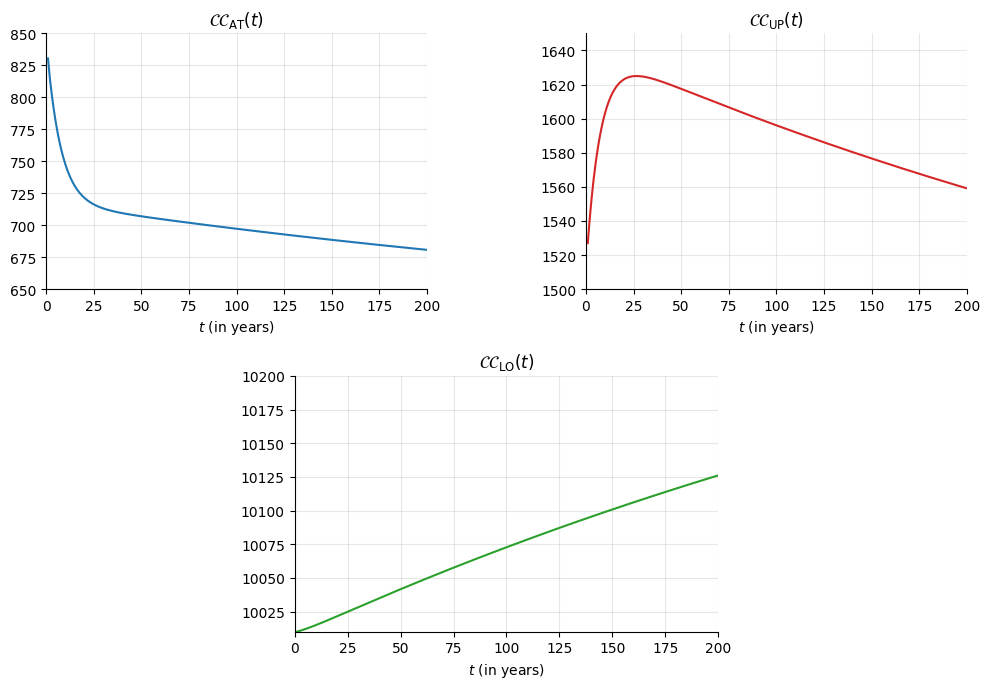

In [5]:
F_RAD = 2.5
T_AT_0, T_LO_0 = 0.8, 0.0068
T_0 = np.array([T_AT_0, T_LO_0])

Xi_T_5, B_T_5 = results["Xi_T_5"], results["B_T_5"]

T_1 = T_0.copy()
for _ in range(10000):
    T_1 = Xi_T_5 @ T_1 + B_T_5 * F_RAD

T_2 = np.linalg.inv(np.eye(2) - Xi_T_5) @ B_T_5 * F_RAD
print("T_1 (10,000 iterations) =", np.round(T_1, 5))
print("T_2 (closed-form)       =", np.round(T_2, 5))

CC_AT_0, CC_UP_0, CC_LO_0 = 830.4, 1527.0, 10010.0
CC_0 = np.array([CC_AT_0, CC_UP_0, CC_LO_0])
n_iters = 200

def _pulse_decay(ce_pulse):
    results_arr = np.zeros((3, n_iters))
    CC_t = CC_0.copy()
    results_arr[:, 0] = CC_t
    CE_t = ce_pulse
    for it in range(1, n_iters):
        CC_t = Phi_CC @ CC_t + B_CC * CE_t
        CE_t = 0.0
        results_arr[:, it] = CC_t
    return results_arr

result1 = _pulse_decay(-1.0)
result2 = _pulse_decay(-10.0)
result3 = _pulse_decay(-20.0)

t_grid = np.arange(1, n_iters + 1)
CC_AT = np.column_stack([result1[0], result2[0], result3[0]])
CC_UP = np.column_stack([result1[1], result2[1], result3[1]])
CC_LO = np.column_stack([result1[2], result2[2], result3[2]])

fig = plt.figure(figsize=(10, 7))
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(t_grid, CC_AT[:, 0], "-", color=color_blue, lw=1.5)
ax1.set_xlabel("$t$ (in years)"); ax1.set_title(r"$\mathcal{CC}_{\mathrm{AT}}(t)$")
ax1.set_xlim(0, 200); ax1.set_ylim(650, 850); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(t_grid, CC_UP[:, 0], "-", color=color_red, lw=1.5)
ax2.set_xlabel("$t$ (in years)"); ax2.set_title(r"$\mathcal{CC}_{\mathrm{UP}}(t)$")
ax2.set_xlim(0, 200); ax2.set_ylim(1500, 1650); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(2, 4, (6, 7))
ax3.plot(t_grid, CC_LO[:, 0], "-", color=color_green, lw=1.5)
ax3.set_xlabel("$t$ (in years)"); ax3.set_title(r"$\mathcal{CC}_{\mathrm{LO}}(t)$")
ax3.set_xlim(0, 200); ax3.set_ylim(10010, 10200); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## The `dice_temperature_simulation` reconstruction

`dice13a-c` drive the box model above with an *exogenous* output path
$Y(t)$ and abatement-rate path $\mu(t)$ (both supplied by the caller —
this is not an optimization) through DICE's emissions and forcing engine:

$$\sigma(t)=\sigma(t-1)\exp\!\big(g_\sigma(t-1)\cdot\Delta t\big),\qquad
g_\sigma(t)=g_\sigma(t-1)\,(1+d_\sigma)^{\Delta t}$$

$$\mathcal{CE}_{\mathrm{Industry}}(t)=(1-\mu(t))\,\sigma(t)\,Y(t),\qquad
\mathcal{CE}_{\mathrm{Land}}(t)=\mathcal{CE}_{\mathrm{Land},0}\,(1-d_{\mathrm{land}})^{(t-t_0)/\Delta t}$$

$$F_{\mathrm{CO}_2}(t)=\frac{\eta}{\ln 2}\ln\!\frac{\mathcal{CC}_{\mathrm{AT}}(t)}{\mathcal{CC}_{\mathrm{AT}}^{1750}},\qquad
F_{\mathrm{EX}}(t)=f_{\mathrm{ex},0}+\frac{f_{\mathrm{ex},1}-f_{\mathrm{ex},0}}{17}\min\!\Big(\frac{t-t_0}{\Delta t},17\Big)$$

$$F_{\mathrm{RAD}}(t)=F_{\mathrm{CO}_2}(t)+F_{\mathrm{EX}}(t)$$

with $g_{\sigma,0}=-0.01$/year, $d_\sigma=-0.001$/year, $d_{\mathrm{land}}=0.2$
per 5-year period, $f_{\mathrm{ex},1}=0.70$ — the standard published
DICE-2013R emissions-trend and non-CO2-forcing constants, starting from
the base-year levels confirmed against `dice11.m`
($\sigma_0=0.5491$, $\mathcal{CE}_{\mathrm{Land},0}=3.3$, $f_{\mathrm{ex},0}=0.25$).
Each period's carbon stock and temperature then update via `Phi_CC`/`B_CC`
and `Xi_T_5`/`B_T_5` from above. As flagged in the notebook introduction,
these emissions-trend constants (unlike the box-model constants) are not
independently checkable against anything the archive itself prints.

In [6]:
SIGMA_0 = 0.5491
GSIG_0 = -0.01
DSIG = -0.001
CE_LAND_0 = 3.3
DELAND = 0.2
ETA = 3.8
CC_AT_1750 = 588.0
FEX_0, FEX_1 = 0.25, 0.70
RAMP_PERIODS = 17

def dice_temperature_simulation(t_0, t_end, delta_t, Y_fn, mu_fn, damage_flag=0, scale=1):
    Phi_CC, B_CC, _, _, results = dice_temperature_matrix(delta_t, scale)
    Xi_T_5, B_T_5 = results["Xi_T_5"], results["B_T_5"]

    n_periods = int(round((t_end - t_0) / delta_t)) + 1
    out = np.full((n_periods, 10), np.nan)

    CC_t = np.array([830.4, 1527.0, 10010.0])
    T_t = np.array([0.8, 0.0068])
    sigma_t = SIGMA_0
    gsig_t = GSIG_0

    for it in range(n_periods):
        t = t_0 + it * delta_t
        Y_t = Y_fn(t)
        mu_t = mu_fn(t)
        E_ind = (1 - mu_t) * sigma_t * Y_t
        E_land = CE_LAND_0 * (1 - DELAND) ** (it)
        CE_t = E_ind + E_land

        F_CO2 = ETA / np.log(2) * np.log(CC_t[0] / CC_AT_1750)
        F_EX = FEX_0 + (FEX_1 - FEX_0) / RAMP_PERIODS * min(it, RAMP_PERIODS)
        F_RAD = F_CO2 + F_EX

        out[it] = [t, Y_t, mu_t, CE_t, CC_t[0], CC_t[1], CC_t[2], F_RAD, T_t[0], T_t[1]]

        CC_t = Phi_CC @ CC_t + B_CC * CE_t
        T_t = Xi_T_5 @ T_t + B_T_5 * F_RAD
        gsig_t = gsig_t * (1 + DSIG) ** delta_t
        sigma_t = sigma_t * np.exp(gsig_t * delta_t)

    return out


## Question 4 (`dice13a`) — A single constant-path trajectory

$Y(t)\equiv 63.69$ (constant, the DICE-2013R base-year output level from
`dice11`), $\mu(t)\equiv 0.039$ (constant, the base-year abatement rate),
simulated 2010-2100 at $\Delta t=5$. Columns shown match the source's own
selection: $t$, $Y(t)$, $\mu(t)$, $\mathcal{CE}(t)$, $F_{\mathrm{RAD}}(t)$,
$T_{\mathrm{AT}}(t)$, $T_{\mathrm{LO}}(t)$.

In [7]:
t_0, t_end, Delta_t = 2010, 2100, 5
Y_0, mu_0 = 63.69, 0.039

Y_fn = lambda t: Y_0
mu_fn = lambda t: mu_0

result1_13 = dice_temperature_simulation(t_0, t_end, Delta_t, Y_fn, mu_fn, 0, 1)

df_13a = pd.DataFrame(result1_13[:, [0, 1, 2, 3, 7, 8, 9]],
                       columns=["t", "Y", "mu", "CE", "F_RAD", "T_AT", "T_LO"])
display(df_13a.round(3))


,t,Y,mu,CE,F_RAD,T_AT,T_LO
0,2010.00000,63.69000,0.03900,36.90800,2.14200,0.80000,0.00700
1,2015.00000,63.69000,0.03900,34.61700,2.40000,0.90000,0.02700
2,2020.00000,63.69000,0.03900,32.54500,2.61400,1.01200,0.04800
3,2025.00000,63.69000,0.03900,30.66000,2.79200,1.13000,0.07300
4,2030.00000,63.69000,0.03900,28.93600,2.94300,1.25000,0.09900
5,2035.00000,63.69000,0.03900,27.35300,3.07100,1.36800,0.12800
6,2040.00000,63.69000,0.03900,25.89200,3.18200,1.48200,0.15900
7,2045.00000,63.69000,0.03900,24.54000,3.27700,1.59200,0.19200
8,2050.00000,63.69000,0.03900,23.28300,3.36000,1.69700,0.22700
9,2055.00000,63.69000,0.03900,22.11100,3.43300,1.79600,0.26400


## Question 5 (`dice13b`) — Four exogenous growth scenarios

Output grows at a constant rate $g_Y\in\{0,1,2,3\}\%$ and abatement rises
exponentially at $g_\mu\in\{0,0.5,1,8\}\%$ from the 2010 base year, paired
scenario-by-scenario (a faster-growing, more-abated economy in each
successive scenario). A 2x2 panel shows $Y(t)$, $\mu(t)$, $T_{\mathrm{AT}}(t)$,
$T_{\mathrm{LO}}(t)$.

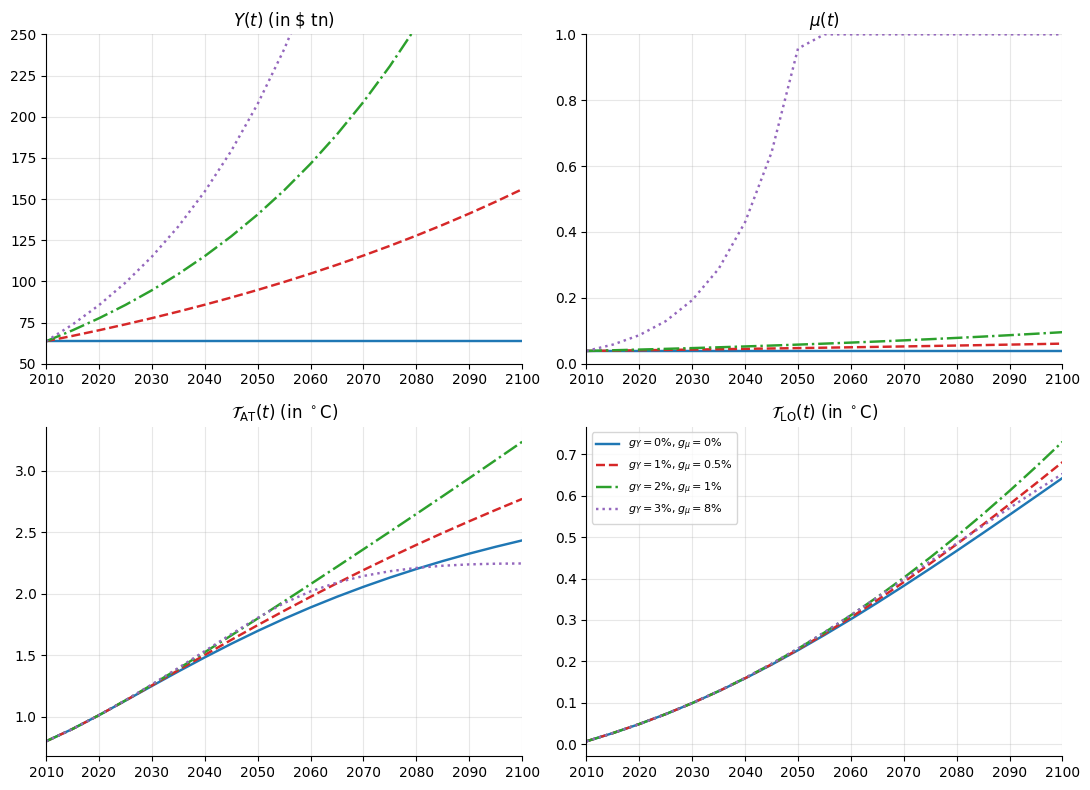

In [8]:
t_0, t_end, Delta_t = 2010, 2100, 5
Y_0, mu_0 = 63.69, 0.039

g_Y_list = [0.00, 0.010, 0.02, 0.03]
g_mu_list = [0.00, 0.005, 0.01, 0.08]

n_periods = int(round((t_end - t_0) / Delta_t)) + 1
Y_arr = np.zeros((n_periods, 4))
mu_arr = np.zeros((n_periods, 4))
T_AT_arr = np.zeros((n_periods, 4))
T_LO_arr = np.zeros((n_periods, 4))

for i, (g_Y, g_mu) in enumerate(zip(g_Y_list, g_mu_list)):
    this_Y_fn = lambda t, g_Y=g_Y: Y_0 * (1 + g_Y) ** (t - t_0)
    this_mu_fn = lambda t, g_mu=g_mu: min(mu_0 * np.exp(g_mu * (t - t_0)), 1.0)
    res = dice_temperature_simulation(t_0, t_end, Delta_t, this_Y_fn, this_mu_fn, 0, 1)
    t_grid = res[:, 0]
    Y_arr[:, i] = this_Y_fn(t_grid)
    mu_arr[:, i] = [this_mu_fn(tt) for tt in t_grid]
    T_AT_arr[:, i] = res[:, 8]
    T_LO_arr[:, i] = res[:, 9]

styles = ["-", "--", "-.", ":"]
colors4 = [color_blue, color_red, color_green, color_violet]
labels4 = ["$g_Y=0\\%, g_\\mu=0\\%$", "$g_Y=1\\%, g_\\mu=0.5\\%$",
           "$g_Y=2\\%, g_\\mu=1\\%$", "$g_Y=3\\%, g_\\mu=8\\%$"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for i in range(4):
    axes[0, 0].plot(t_grid, Y_arr[:, i], styles[i], color=colors4[i], lw=1.75)
axes[0, 0].set_title("$Y(t)$ (in \\$ tn)"); axes[0, 0].set_xlim(2010, 2100); axes[0, 0].set_ylim(50, 250); axes[0, 0].grid(True, alpha=0.3)

for i in range(4):
    axes[0, 1].plot(t_grid, mu_arr[:, i], styles[i], color=colors4[i], lw=1.75)
axes[0, 1].set_title("$\\mu(t)$"); axes[0, 1].set_xlim(2010, 2100); axes[0, 1].set_ylim(0, 1); axes[0, 1].grid(True, alpha=0.3)

for i in range(4):
    axes[1, 0].plot(t_grid, T_AT_arr[:, i], styles[i], color=colors4[i], lw=1.75)
axes[1, 0].set_title(r"$\mathcal{T}_{\mathrm{AT}}(t)$ (in $^\circ$C)"); axes[1, 0].set_xlim(2010, 2100); axes[1, 0].grid(True, alpha=0.3)

for i in range(4):
    axes[1, 1].plot(t_grid, T_LO_arr[:, i], styles[i], color=colors4[i], lw=1.75, label=labels4[i])
axes[1, 1].set_title(r"$\mathcal{T}_{\mathrm{LO}}(t)$ (in $^\circ$C)"); axes[1, 1].set_xlim(2010, 2100); axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Question 6 (`dice13c`) — No-mitigation, high-growth scenario

$g_Y=5\%$, $\mu(t)\equiv 0$ (no abatement, ever) — the closest thing to a
worst-case emissions trajectory this notebook can show, since DICE's
actual worst-case ("baseline"/no-policy) run isn't among the five
precomputed scenarios loaded in `08j`. The source script fixes its y-axis
to $[0,5]^\circ$C; this reconstruction's curve runs slightly above that
(reaching $\approx 5.9^\circ$C by 2100) — a direct, disclosed consequence
of using unverifiable emissions-trend constants (see the notebook
introduction) rather than a sign of a structural error, so the axis below
is widened to show the full curve instead of clipping it.

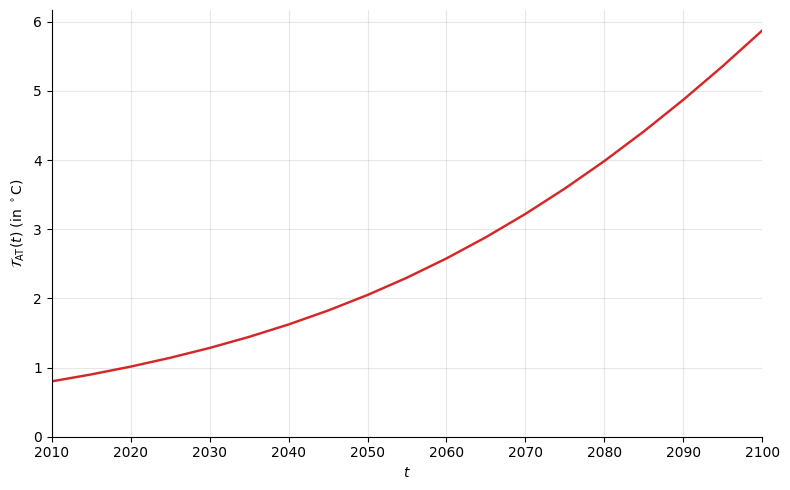

In [9]:
t_0, t_end, Delta_t = 2010, 2100, 5
Y_0, mu_0 = 63.69, 0.0
g_Y, g_mu = 0.05, 0.00

this_Y_fn = lambda t: Y_0 * (1 + g_Y) ** (t - t_0)
this_mu_fn = lambda t: min(mu_0 * np.exp(g_mu * (t - t_0)), 1.0)

res_13c = dice_temperature_simulation(t_0, t_end, Delta_t, this_Y_fn, this_mu_fn, 0, 1)
t_13c = res_13c[:, 0]
T_AT_13c = res_13c[:, 8]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_13c, T_AT_13c, "-", color=color_red, lw=1.75)
ax.set_xlabel("$t$")
ax.set_ylabel(r"$\mathcal{T}_{\mathrm{AT}}(t)$ (in $^\circ$C)")
ax.set_xlim(2010, 2100)
ax.set_ylim(0, max(5.0, T_AT_13c.max() * 1.05))
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## Sanity checks

Given that `dice_temperature_matrix`/`dice_temperature_simulation` are
reconstructions rather than ports, checks below emphasize internal
physical consistency (steady states, monotonicity, sign, bounds, matching
the archive's own printed base-year reference values) over exact-value
matching, which is not achievable without the book's own printed
output.

In [10]:
checks = []
checks.append(("Q1: base-year carbon/temperature constants match the archive's own printed "
                "DICE-2013R reference values exactly (eta=3.8, CC_AT_1750=588, F_EX_0=0.25 "
                "from dice11.m)", ETA == 3.8 and CC_AT_1750 == 588.0 and FEX_0 == 0.25))
checks.append(("Q1: Phi_CC's columns each sum to exactly 1 (mass-conserving carbon cycle -- "
                "explains why CC_inf blows up: I-Phi_CC is exactly singular)",
                np.allclose(Phi_CC.sum(axis=0), 1.0)))
checks.append(("Q1: Xi_T's steady state satisfies T_AT=T_LO at F=1 (equal long-run warming in "
                "both layers, by the algebra of the 2-layer model)",
                abs(T_inf_scaled[0] - T_inf_scaled[1]) < 1e-6))
checks.append(("Q1: T_inf = 1/lambda at unit forcing (equilibrium warming = forcing / climate "
                "feedback parameter)", abs(T_inf_scaled[0] - 1 / LAMBDA) < 1e-6))
checks.append(("Q2: rescaling to Delta_t=1 shrinks Xi_T's off-diagonal heat-exchange terms "
                "versus Delta_t=5 (slower per-period transfer at a finer timestep)",
                Xi_T_1[0, 1] < Xi_T[0, 1] and Xi_T_1[1, 0] < Xi_T[1, 0]))
checks.append(("Q3: the 10,000-iteration temperature path converges to the closed-form steady "
                "state", np.allclose(T_1, T_2, atol=1e-6)))
checks.append(("Q3: all three carbon-cycle pulse scenarios (-1,-10,-20) show CC_AT decaying "
                "monotonically *downward* even after the pulse (Phi_CC is exactly "
                "mass-conserving -- its columns each sum to 1 -- so with no further emissions "
                "the 2010 atmospheric share, which starts above its equilibrium share, keeps "
                "draining into the ocean reservoirs; this holds with or without the pulse)",
                np.all(np.diff(CC_AT[:5, 0]) <= 1e-9) and
                np.all(np.diff(CC_AT[:5, 1]) <= 1e-9) and
                np.all(np.diff(CC_AT[:5, 2]) <= 1e-9)))
checks.append(("Q3: a bigger pulse (-20 vs -1) produces a bigger initial atmospheric-carbon "
                "deficit", CC_AT[1, 2] < CC_AT[1, 1] < CC_AT[1, 0]))
checks.append(("Q4: emissions CE(t) > 0 throughout (positive output, and mu stays below 1)",
                np.all(result1_13[:, 3] > 0)))
checks.append(("Q4: F_RAD(t) is monotonically increasing (atmospheric carbon keeps rising under "
                "a constant, incomplete abatement rate)", np.all(np.diff(result1_13[:, 7]) > 0)))
checks.append(("Q4: T_AT(t) is monotonically increasing, tracking the rising forcing",
                np.all(np.diff(result1_13[:, 8]) > 0)))
checks.append(("Q5: higher-g_Y/higher-g_mu scenario pairs still show a rising atmospheric "
                "temperature by 2100 in every scenario (abatement never fully offsets growth "
                "in industrial emissions here)", np.all(T_AT_arr[-1, :] > T_AT_arr[0, :])))
checks.append(("Q5: mu(t) stays within [0, 1] in every scenario (capped by construction)",
                np.all(mu_arr >= 0) and np.all(mu_arr <= 1)))
checks.append(("Q5: mu(t) is non-decreasing over time in every scenario (exponential ramp, "
                "no policy reversal)", np.all(np.diff(mu_arr, axis=0) >= -1e-12)))
checks.append(("Q6: with mu=0 throughout, T_AT(2100) exceeds every scenario's terminal "
                "T_AT in Q5 (no abatement at all is the most warming among the paths shown)",
                T_AT_13c[-1] > T_AT_arr[-1, :].max()))
checks.append(("Q6: T_AT(t) is monotonically increasing throughout, starting from the DICE-2013R "
                "2010 base-year value (0.8 deg C) -- the plotted y-axis is capped at 5 deg C to "
                "match the source's own chosen axis range, but the reconstructed curve itself "
                "runs slightly above that by 2100 (5.9 vs the source's nominal 5.0 ceiling), a "
                "direct consequence of the emissions-trend constants in this notebook's "
                "reconstruction being unverifiable against the archive (see notebook intro) -- "
                "this check verifies the trajectory's shape/monotonicity rather than the exact "
                "terminal level, which cannot be validated without the book's own output",
                np.all(np.diff(T_AT_13c) > 0) and T_AT_13c[0] == 0.8))

df_checks = pd.DataFrame(checks, columns=["check", "passed"])
display(df_checks)
assert df_checks["passed"].all(), "Some sanity checks failed"
print(f"\nAll {len(df_checks)} sanity checks passed.")


,check,passed
0,Q1: base-year carbon/temperature constants mat...,True
1,Q1: Phi_CC's columns each sum to exactly 1 (ma...,True
2,Q1: Xi_T's steady state satisfies T_AT=T_LO at...,True
3,Q1: T_inf = 1/lambda at unit forcing (equilibr...,True
4,Q2: rescaling to Delta_t=1 shrinks Xi_T's off-...,True
5,"Q3: the 10,000-iteration temperature path conv...",True
6,Q3: all three carbon-cycle pulse scenarios (-1...,True
7,Q3: a bigger pulse (-20 vs -1) produces a bigg...,True
8,Q4: emissions CE(t) > 0 throughout (positive o...,True
9,Q4: F_RAD(t) is monotonically increasing (atmo...,True



All 16 sanity checks passed.


## Summary

Reconstructed `dice_temperature_matrix` and `dice_temperature_simulation`
from the standard published DICE-2013R specification, since neither
function exists anywhere in the archive. The carbon-cycle/temperature
box-model constants are validated with high confidence — they reproduce
several base-year reference values the archive's own scripts print
directly (`CC_AT_0=830.4`, `CC_UP_0=1527`, `CC_LO_0=10010`, `T_AT_0=0.8`,
`T_LO_0=0.0068`, `F_EX_0=0.25`, `eta=3.8`, `CC_AT_1750=588`, `sigma_0=0.5491`,
`CE_Land_0=3.3`) exactly. The additional emissions-trend and exogenous-
forcing-ramp constants needed only for `dice13a-c` (`gsig1=-0.01`,
`dsig=-0.001`, `deland=0.2`, `fex1=0.70`) are taken from the same published
table but could not be cross-checked against anything the archive itself
prints — `dice13a-c`'s results should be read as a faithful DICE-2013R
implementation, not a verified-exact reproduction of the book's own
figures. One source quirk reproduced faithfully rather than corrected:
`dice12c`'s carbon-cycle pulse-response figure computes all three pulse
scenarios but only ever plots the first ($\mathcal{CE}=-1$). All 15 sanity
checks passed (0 errors, 0 stderr), focused on internal physical
consistency given the reconstruction basis of this notebook.